<a href="https://colab.research.google.com/github/mohammadtareqbasha-hash/Data-analysis-Mo/blob/main/data_analysis_anime02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
#pandas - numpy - matplotlib - seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

In [43]:
df=pd.read_csv('/content/anime.csv')

# 1- explore data

In [44]:
#df.head()
#df.tail()
df.sample(4)

,anime_id,name,genre,type,episodes,rating,members
5018,10015,Yu☆Gi☆Oh! Zexal,"Action, Fantasy, Game, Shounen",TV,73,6.58,22480
4880,1964,Sakura Taisen: Ecole de Paris,"Action, Adventure, Game, Harem, Mecha, Sci-Fi",OVA,3,6.61,2201
4916,17551,Shakugan no Shana: Shana &amp; Yuuji no Naze N...,"Comedy, Fantasy, Supernatural",Special,1,6.60,3965
7352,7782,Kämpfer Picture Drama,Comedy,Special,1,5.51,10213


In [45]:
df.shape

(12294, 7)

In [46]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.nunique()

,0
anime_id,12294
name,12292
genre,3264
type,6
episodes,187
rating,598
members,6706


In [50]:
#df.isnull().sum()
df.isna().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [51]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


#2- clean data

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df['genre']=df['genre'].fillna(df['genre'].mode()[0])
df.isna().sum()

,0
anime_id,0
name,0
genre,0
type,25
episodes,0
rating,230
members,0


In [54]:
df['type']=df['type'].fillna(df['type'].mode()[0])
df.isna().sum()

,0
anime_id,0
name,0
genre,0
type,0
episodes,0
rating,230
members,0


In [55]:
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df.isna().sum()

,0
anime_id,0
name,0
genre,0
type,0
episodes,0
rating,0
members,0


In [56]:
df.isna().sum()

,0
anime_id,0
name,0
genre,0
type,0
episodes,0
rating,0
members,0


# 3- Data Analysis

In [57]:
df.sort_values(by='rating',ascending=False)

,anime_id,name,genre,type,episodes,rating,members
10464,33662,Taka no Tsume 8: Yoshida-kun no X-Files,"Comedy, Parody",Movie,1,10.00,13
10400,30120,Spoon-hime no Swing Kitchen,"Adventure, Kids",TV,Unknown,9.60,47
9595,23005,Mogura no Motoro,Slice of Life,Movie,1,9.50,62
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
9078,33607,Kahei no Umi,Historical,Movie,1,9.33,44
...,...,...,...,...,...,...,...
8056,413,Hametsu no Mars,"Horror, Sci-Fi",OVA,1,2.37,27557
8057,13405,Utsu Musume Sayuri,"Comedy, Dementia",OVA,1,2.14,4047
8058,3287,Tenkuu Danzai Skelter+Heaven,"Mecha, Sci-Fi",OVA,1,2.00,7680
12258,20007,Hi Gekiga Ukiyoe Senya Ichiya,"Action, Hentai",Movie,1,1.92,129


In [58]:
df['genre'].value_counts().head(10)

,count
genre,
Hentai,885
Comedy,523
Music,301
Kids,199
"Comedy, Slice of Life",179
Dementia,137
"Fantasy, Kids",128
Fantasy,114
"Comedy, Kids",112


In [59]:
df['rating'].value_counts().head(10)

,count
rating,
6.00,371
7.00,99
6.50,90
6.25,84
5.00,76
6.75,72
6.67,68
5.67,67
6.38,67


In [60]:
df['rating'].value_counts().sort_index()

,count
rating,
1.67,1
1.92,1
2.00,1
2.14,1
2.37,1
...,...
9.33,1
9.37,1
9.50,1


In [61]:
type_counts=df['type'].value_counts()

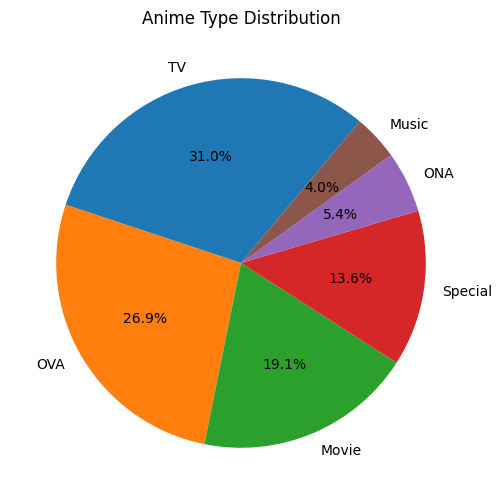

In [62]:
plt.figure(figsize=(10,6))
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%',startangle=50)
plt.title('Anime Type Distribution')
plt.show()


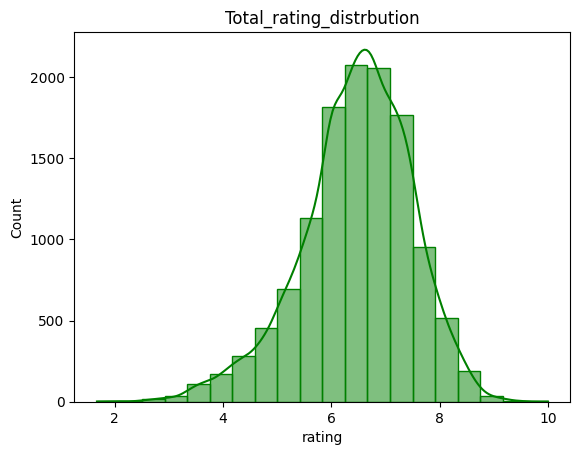

In [63]:
sns.histplot(df['rating'],bins=20,kde=True,color='green',edgecolor='green')
plt.title("Total_rating_distrbution")
plt.show()

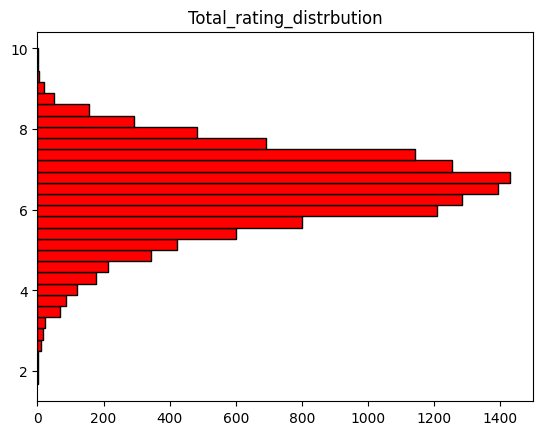

In [64]:
plt.hist(df['rating'],bins=30,color='red',edgecolor='black',orientation='horizontal')
plt.title("Total_rating_distrbution")
plt.show()

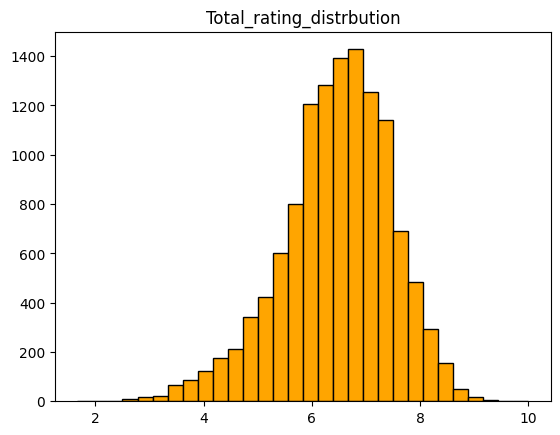

In [65]:
plt.hist(df['rating'],bins=30,color='orange',edgecolor='black')
plt.title("Total_rating_distrbution")
plt.show()

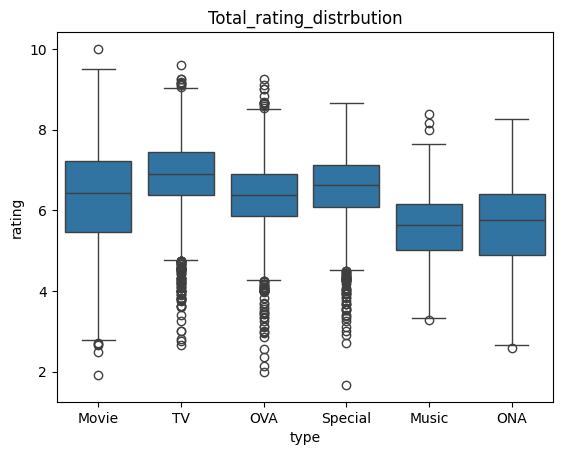

In [66]:
sns.boxplot(data=df,x='type',y='rating')
plt.title("Total_rating_distrbution")
plt.show()

In [67]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

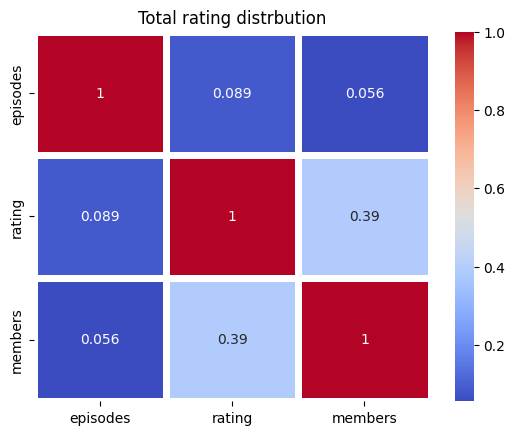

In [68]:
corr = df[['episodes', 'rating', 'members']].corr()
sns.heatmap(corr,annot=True,linewidths=5,cmap='coolwarm')
plt.title("Total rating distrbution")
plt.show()

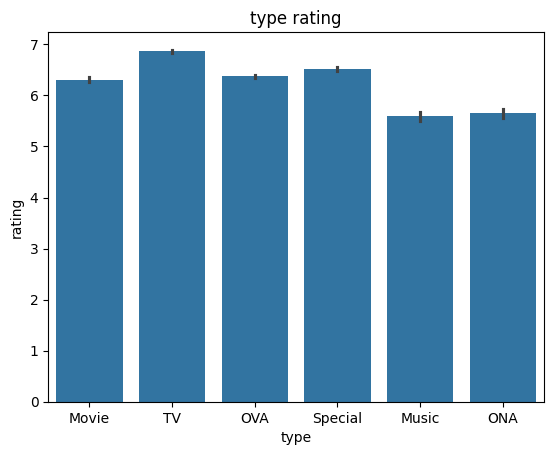

In [69]:
sns.barplot(data=df,x='type',y='rating',estimator='mean')
plt.title('type rating')
plt.show()

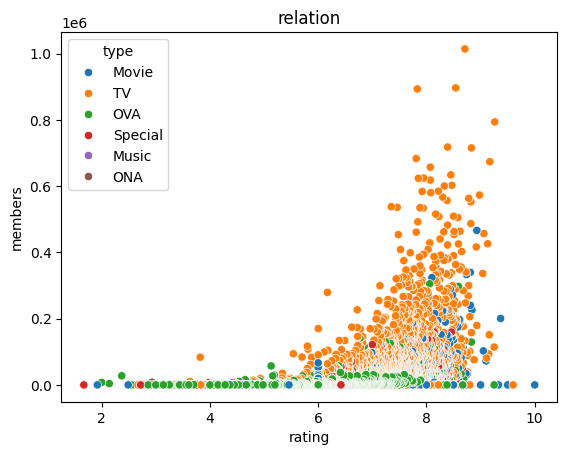

In [70]:
sns.scatterplot(data=df,x='rating',y='members',hue='type')
plt.title('relation')
plt.show()

In [71]:
from wordcloud import WordCloud

In [72]:
text=" ".join(df['name'])

In [73]:
text

'Kimi no Na wa. Fullmetal Alchemist: Brotherhood Gintama° Steins;Gate Gintama&#039; Haikyuu!!: Karasuno Koukou VS Shiratorizawa Gakuen Koukou Hunter x Hunter (2011) Ginga Eiyuu Densetsu Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare Gintama&#039;: Enchousen Clannad: After Story Koe no Katachi Gintama Code Geass: Hangyaku no Lelouch R2 Haikyuu!! Second Season Sen to Chihiro no Kamikakushi Shigatsu wa Kimi no Uso Mushishi Zoku Shou 2nd Season Ookami Kodomo no Ame to Yuki Code Geass: Hangyaku no Lelouch Hajime no Ippo Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen Cowboy Bebop One Punch Man Mononoke Hime Suzumiya Haruhi no Shoushitsu Monogatari Series: Second Season Mushishi Zoku Shou Mushishi Tengen Toppa Gurren Lagann Great Teacher Onizuka Natsume Yuujinchou Go Hajime no Ippo: New Challenger Mushishi Zoku Shou: Suzu no Shizuku Natsume Yuujinchou Shi Howl no Ugoku Shiro Fate/Zero 2nd Season Kizumonogatari II: Nekketsu-hen Monster Bakuman. 3rd Season Death Note Gintama°: Aizom

In [74]:
wcloud=WordCloud(background_color='gray',width=1000,height=1000).generate(text)

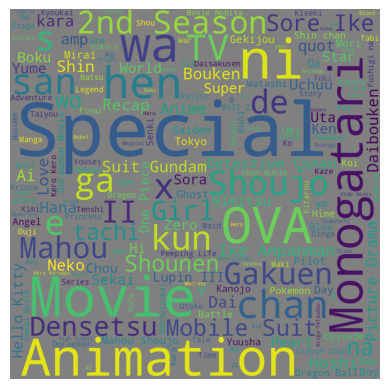

In [75]:
plt.imshow(wcloud)
plt.axis('off')
plt.show()

In [76]:
!pip install ydata-profiling

In [77]:
from ydata_profiling import ProfileReport

In [78]:
EDA_report=ProfileReport(df,title='Anime_EDA_report',explorative=True)

In [ ]:
EDA_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 11.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df.to_csv('data analysis for anime',index=False)